In [6]:
import numpy as np
import matplotlib.pyplot as plt

def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)  # Step sizes: h[i] is x[i+1] - x[i]
    
    # Initialize the tridiagonal matrix coefficients for (n-2) internal equations
    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector
    
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):

        A[i - 1] = h[i - 1] #Subdiagonal
        B[i - 1] = 2 * (h[i - 1] + h[i]) #Main diagonal
        C[i - 1] = h[i] #Superdiagonal
        D[i - 1] = 6 * (((y[i + 1] - y[i]) / h[i]) - (y[i] - y[i - 1]) / (h[i - 1])) #Right-hand side vector

    return A, B, C, D

def thomas_algorithm(a, b, c, d):
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

def evaluate_spline(x_orig, y_orig, M, x_eval):
    y_eval = []
    h = np.diff(x_orig)
    for val in x_eval:
        # Find interval
        idx = np.searchsorted(x_orig, val) - 1
        idx = max(0, min(idx, len(x_orig) - 2))
        
        dx = val - x_orig[idx]
        hi = h[idx]
        
        # Cubic Spline Formula
        term1 = M[idx] * (x_orig[idx+1] - val)**3 / (6 * hi)
        term2 = M[idx+1] * (val - x_orig[idx])**3 / (6 * hi)
        term3 = (y_orig[idx] - M[idx] * hi**2 / 6) * (x_orig[idx+1] - val) / hi
        term4 = (y_orig[idx+1] - M[idx+1] * hi**2 / 6) * (val - x_orig[idx]) / hi
        y_eval.append(term1 + term2 + term3 + term4)
    return np.array(y_eval)

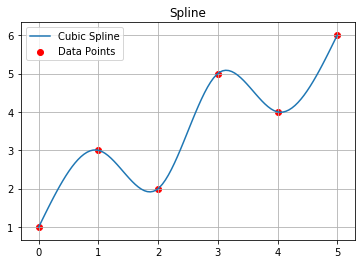

In [7]:
#Data Points
x_data = np.array([0, 1, 2, 3, 4, 5])
y_data = np.array([1, 3, 2, 5, 4, 6])

#Second Derivatives (M)
A, B, C, D = setup_tridiagonal_matrix(x_data, y_data)
M_internal = thomas_algorithm(A, B, C, D)

#Clamp
M = np.concatenate(([0], M_internal, [0]))

#Plot
x_vals = np.linspace(0, 5, 100)
y_vals = evaluate_spline(x_data, y_data, M, x_vals)

#Graph
plt.plot(x_vals, y_vals, label='Cubic Spline')
plt.scatter(x_data, y_data, color='red', label='Data Points')
plt.title("Spline")
plt.grid(True)
plt.legend()
plt.show()